# Phase 6: From Saliency to Concepts

Phase 6 moves from pixel-level explanations to AwA2 semantic attributes.

The goal is not yet full TCAV. This phase builds the concept layer needed before TCAV:

- load AwA2 class attributes;
- inspect the strongest concepts for each animal;
- connect Phase 4/5 prediction flips to semantic concept differences;
- save CSV reports and figures for the blog post.


In [1]:
from pathlib import Path
from IPython.display import Image, display
import subprocess
import sys

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

CANDIDATE_MANIFESTS = [
    PROJECT_ROOT / 'data' / 'AWA2_subset_background20' / 'awa2_manifest_subset.csv',
    PROJECT_ROOT / 'data' / 'AWA2' / 'awa2_manifest_debug.csv',
    PROJECT_ROOT / 'data' / 'AWA2' / 'awa2_manifest.csv',
]
MANIFEST = next((path for path in CANDIDATE_MANIFESTS if path.exists()), None)
if MANIFEST is None:
    raise FileNotFoundError('No AwA2 manifest found.')

METADATA_ROOT = PROJECT_ROOT / 'data' / 'AWA2'
STRESS_CSV = PROJECT_ROOT / 'outputs' / 'reports' / 'phase5_saliency_metrics_notebook.csv'
if not STRESS_CSV.exists():
    STRESS_CSV = PROJECT_ROOT / 'outputs' / 'reports' / 'phase5_saliency_metrics.csv'

CLASS_PROFILE_CSV = PROJECT_ROOT / 'outputs' / 'reports' / 'phase6_class_concepts_notebook.csv'
TRANSITION_CSV = PROJECT_ROOT / 'outputs' / 'reports' / 'phase6_concept_transitions_notebook.csv'
HEATMAP_OUTPUT = PROJECT_ROOT / 'outputs' / 'figures' / 'phase6_class_concept_heatmap_notebook.png'
TRANSITION_FIGURE = PROJECT_ROOT / 'outputs' / 'figures' / 'phase6_concept_transition_examples_notebook.png'

print('manifest:', MANIFEST)
print('metadata_root:', METADATA_ROOT)
print('stress_csv:', STRESS_CSV, 'exists=', STRESS_CSV.exists())


manifest: /home/emma/DeepLearning/Deep_Learning_XAI/data/AWA2_subset_background20/awa2_manifest_subset.csv
metadata_root: /home/emma/DeepLearning/Deep_Learning_XAI/data/AWA2
stress_csv: /home/emma/DeepLearning/Deep_Learning_XAI/outputs/reports/phase5_saliency_metrics_notebook.csv exists= True


## Run the Concept Analysis

This cell reads the AwA2 attributes and creates concept-level reports. If Phase 5 metrics are available, it also analyzes which concepts change when a perturbation changes the predicted animal.


In [3]:
cmd = [
    sys.executable,
    str(PROJECT_ROOT / 'scripts' / 'run_phase6_concepts.py'),
    '--manifest', str(MANIFEST),
    '--metadata-root', str(METADATA_ROOT),
    '--stress-csv', str(STRESS_CSV),
    '--class-profile-output', str(CLASS_PROFILE_CSV),
    '--transition-output', str(TRANSITION_CSV),
    '--heatmap-output', str(HEATMAP_OUTPUT),
    '--transition-figure-output', str(TRANSITION_FIGURE),
    '--top-concepts', '12',
]
print(' '.join(cmd))
completed = subprocess.run(cmd, cwd=PROJECT_ROOT, text=True, capture_output=True)
print(completed.stdout)
print(completed.stderr)
if completed.returncode != 0:
    raise RuntimeError(f'Phase 6 failed with exit code {completed.returncode}')


/home/emma/DeepLearning/.venvDeepLearning/bin/python /home/emma/DeepLearning/Deep_Learning_XAI/scripts/run_phase6_concepts.py --manifest /home/emma/DeepLearning/Deep_Learning_XAI/data/AWA2_subset_background20/awa2_manifest_subset.csv --metadata-root /home/emma/DeepLearning/Deep_Learning_XAI/data/AWA2 --stress-csv /home/emma/DeepLearning/Deep_Learning_XAI/outputs/reports/phase5_saliency_metrics_notebook.csv --class-profile-output /home/emma/DeepLearning/Deep_Learning_XAI/outputs/reports/phase6_class_concepts_notebook.csv --transition-output /home/emma/DeepLearning/Deep_Learning_XAI/outputs/reports/phase6_concept_transitions_notebook.csv --heatmap-output /home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/phase6_class_concept_heatmap_notebook.png --transition-figure-output /home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/phase6_concept_transition_examples_notebook.png --top-concepts 12

2026-07-10 11:05:52 | INFO | run_phase6_concepts | manifest=/home/emma/DeepLearning/Dee

## Inspect Concept Figures

The heatmap shows how classes are described by human concepts. The transition plot shows how much the concept profile changes when the model prediction flips after perturbation.


/home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/phase6_class_concept_heatmap_notebook.png


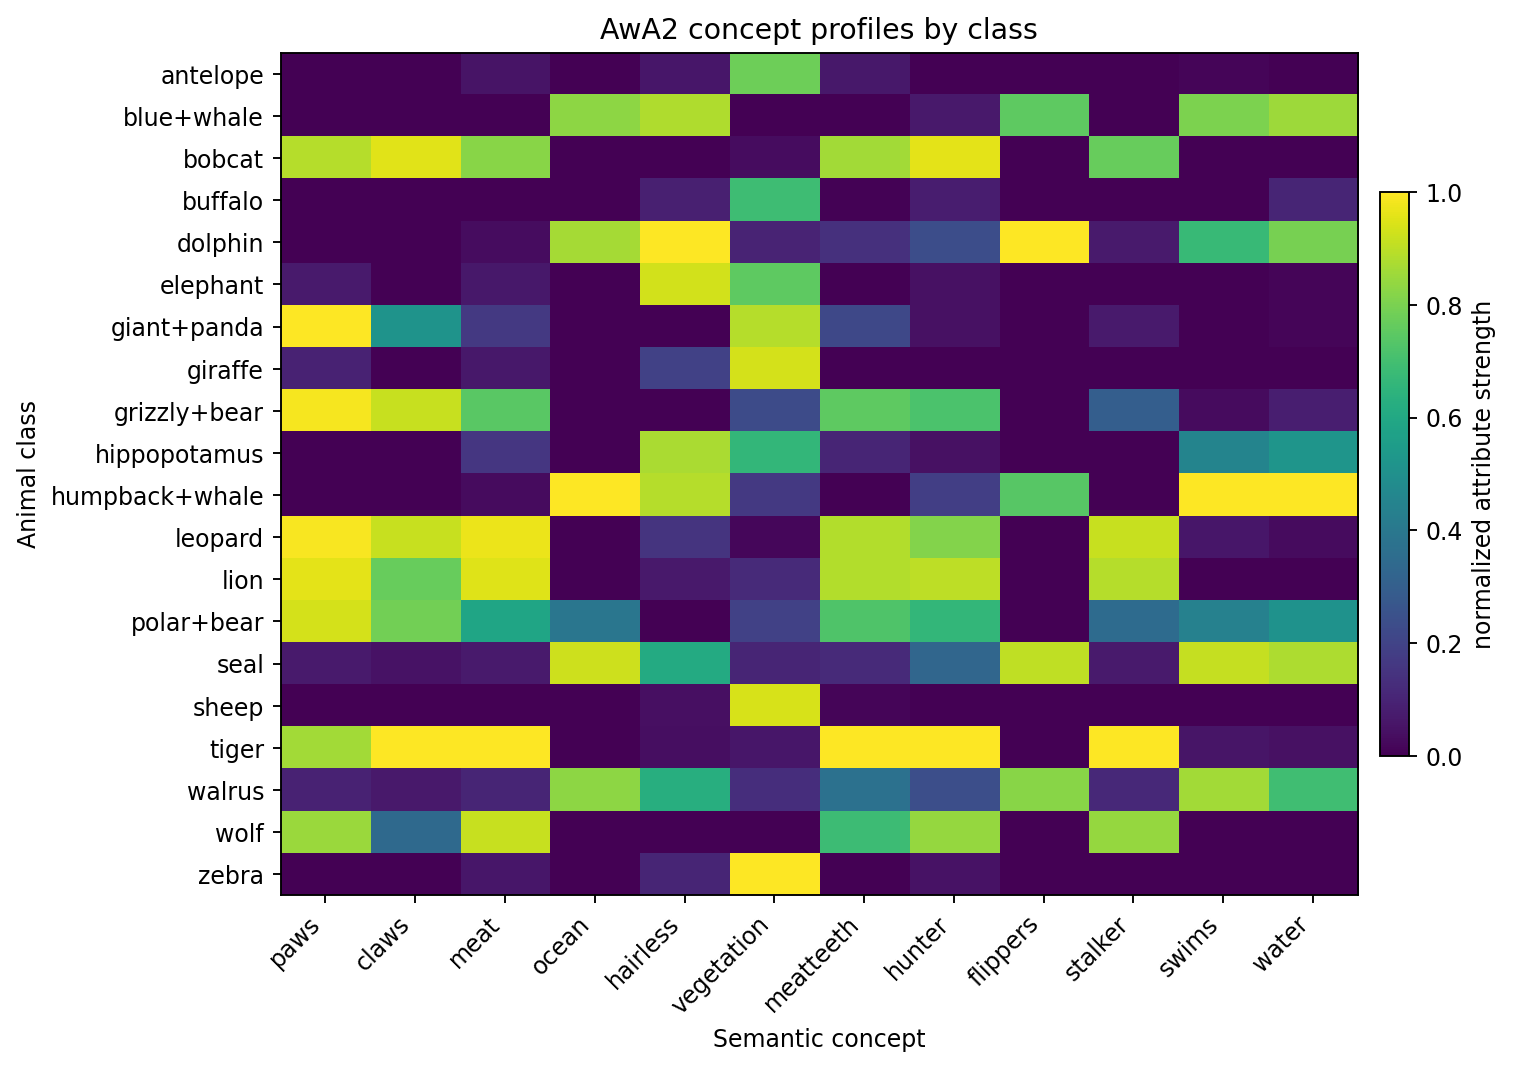

/home/emma/DeepLearning/Deep_Learning_XAI/outputs/figures/phase6_concept_transition_examples_notebook.png


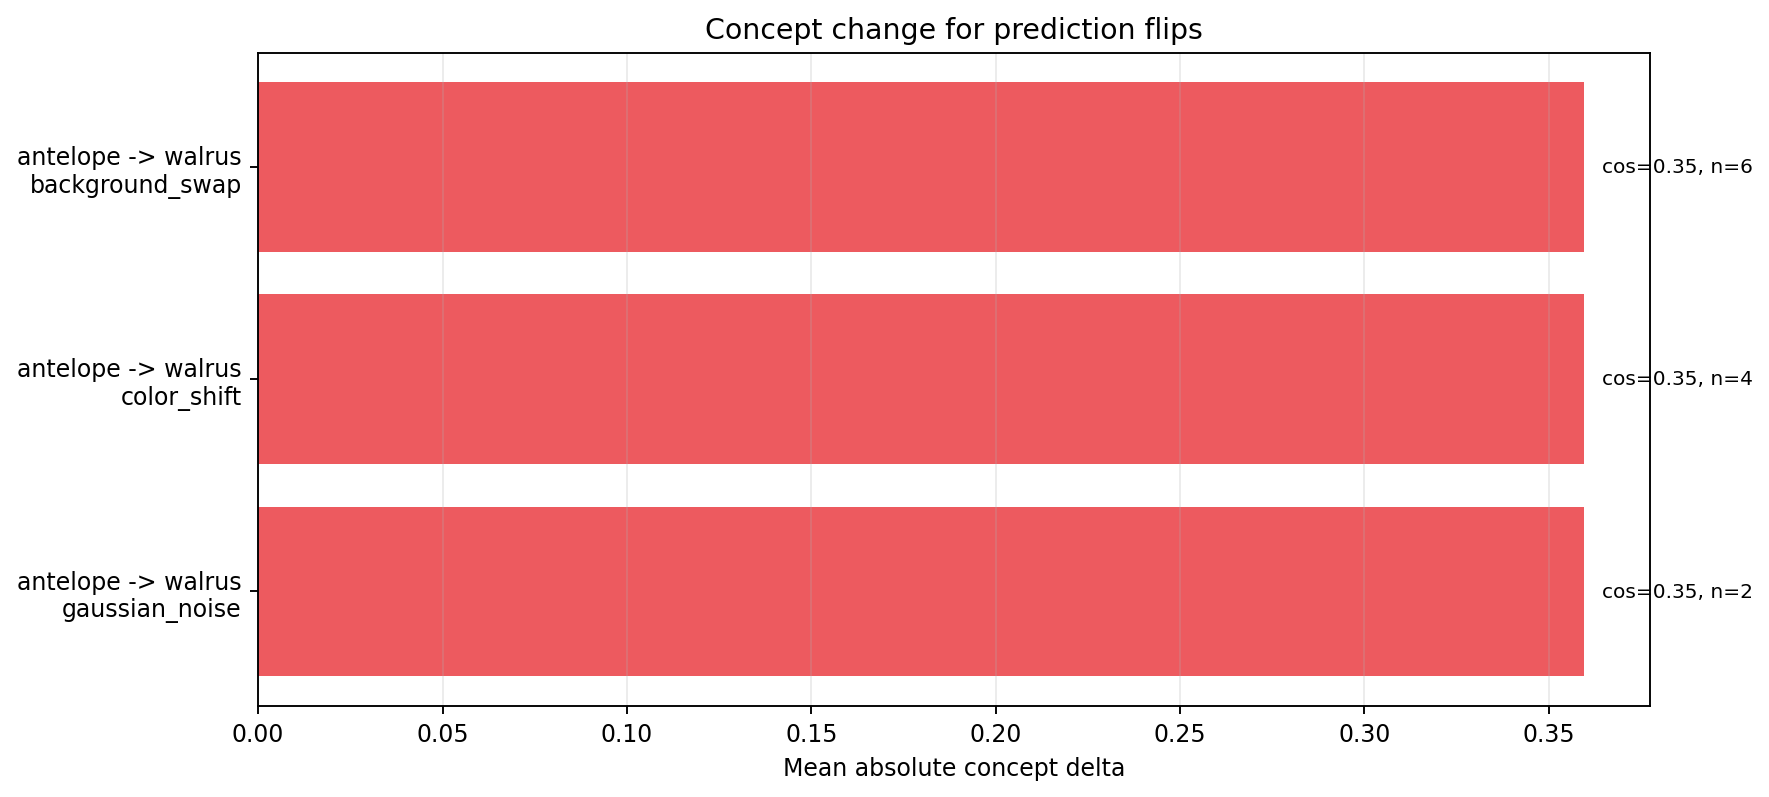

In [4]:
for figure in [HEATMAP_OUTPUT, TRANSITION_FIGURE]:
    print(figure)
    if figure.exists():
        display(Image(filename=str(figure)))
    else:
        print('missing figure:', figure)


## Inspect CSV Reports

`phase6_class_concepts` lists the strongest semantic attributes for each class. `phase6_concept_transitions` explains prediction flips as concept-vector changes.


In [5]:
import csv

for csv_path in [CLASS_PROFILE_CSV, TRANSITION_CSV]:
    print('\n', csv_path)
    if not csv_path.exists():
        print('missing csv')
        continue
    with csv_path.open('r', newline='', encoding='utf-8') as handle:
        rows = list(csv.DictReader(handle))
    print('rows:', len(rows))
    for row in rows[:5]:
        print(row)



 /home/emma/DeepLearning/Deep_Learning_XAI/outputs/reports/phase6_class_concepts_notebook.csv
rows: 20
{'class_name': 'antelope', 'top_concepts': 'insects:1.000; hops:1.000; horns:1.000; hooves:0.877; fast:0.826; agility:0.819; forager:0.818; plains:0.796; grazer:0.786; vegetation:0.777; quadrapedal:0.762; longleg:0.717'}
{'class_name': 'blue+whale', 'top_concepts': 'blue:1.000; strainteeth:1.000; plankton:0.914; skimmer:0.913; big:0.896; hairless:0.880; water:0.852; ocean:0.829; swims:0.804; bulbous:0.794; flippers:0.750; timid:0.677'}
{'class_name': 'bobcat', 'top_concepts': 'solitary:1.000; mountains:1.000; red:1.000; tail:0.965; small:0.961; hunter:0.959; claws:0.956; agility:0.952; forager:0.910; paws:0.889; fast:0.864; meatteeth:0.861'}
{'class_name': 'buffalo', 'top_concepts': 'plains:1.000; newworld:0.900; big:0.876; brown:0.826; walks:0.767; quadrapedal:0.695; vegetation:0.689; grazer:0.687; group:0.644; ground:0.620; bulbous:0.619; forager:0.583'}
{'class_name': 'dolphin', '